# 19_参数估计方法-EM算法

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇使用代码生成的模拟数据或 scikit-learn 随包附带的小数据集，无需外部数据文件。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


这个小节咱们聊聊参数估计方法方面的EM算法\~

在我看来，如果作为初学者，是一种非常常用但又容易让人困惑的算法。

咱们先看一个场景：你要估计模型中的参数，但你手上的数据不完整。

当你是个侦探，你想知道一个罪犯的作案规律（就是我们要估的“参数”），但是你手上的证据（数据）并不是完整的。你只知道他出现过在哪些城市，但不知道他具体干了什么。于是你开始猜测：在当前的证据下，他**最可能做了什么**，然后据此**更新你的判断（参数）**，再根据新的判断继续猜。

这就是 **EM算法的思想**：

> **先“猜”（E步），再“算”（M步），循环直到稳定。**

### 一个简单的例子（猜硬币）

你有两枚硬币A和B，你不知道它们的正面概率（参数pA和pB），这是你要估的。

- 你做实验，每次你随机选一枚硬币，连续抛掷10次，记录正面次数。
- 但是你不知道哪次是用A，哪次是用B抛的（“隐藏信息”）。

于是你怎么办？

1. **你先随便猜一下这10组实验中哪一组更可能是A干的、哪一组是B干的**（期望步骤E-step）。
2. **然后根据你的猜测来重新估计A和B的正面概率pA和pB**（最大化步骤M-step）。
3. **用新的参数再来猜各组实验是A还是B干的**，循环下去，直到猜来猜去都差不多了。

### EM算法解决的问题：含有**隐变量**的概率模型的参数估计

我们的问题是：数据中有些变量是“看不见的”（称为**隐变量 hidden variables**），导致我们不能直接用最大似然估计（MLE）来估参数。

EM算法可以在这种情况下估计模型参数。

## 核心原理

设我们有一组观察到的数据 $X$，但真正生成这些数据的过程涉及一个我们没有观测到的“隐变量” $Z$，比如：

- $X$：观察到的结果（比如抛硬币的正面次数）
- $Z$：哪一枚硬币（我们没看到）
- $\theta$：我们想估计的参数（比如硬币正面朝上的概率）

**我们想要最大化**：


$$
\log p(X | \theta)
$$


但由于隐变量 $Z$ 没有观察到，无法直接计算这个似然函数。于是我们换个思路。

### 核心思想：引入一个“下界”来优化

我们引入一个关于 $Z$ 的分布 $q(Z)$，用来逼近“真实的”隐变量分布。

根据Jensen不等式，有：


$$
\log p(X | \theta) = \log \sum_Z p(X, Z | \theta) \geq \sum_Z q(Z) \log \frac{p(X, Z | \theta)}{q(Z)}
$$


右边这个东西我们记作：


$$
\mathcal{L}(q, \theta) = \sum_Z q(Z) \log \frac{p(X, Z | \theta)}{q(Z)}
$$


这是对真实对数似然的一个**下界**。

EM算法的目标是不断地提高这个下界，直到收敛。

### EM算法的两个步骤

**1. E-step（期望步骤）**：

我们在当前参数 $\theta^{(t)}$ 下，计算隐变量 $Z$ 的后验分布：


$$
q^{(t)}(Z) = p(Z | X, \theta^{(t)})
$$


也就是在当前的参数下，我们“猜”每个隐变量的可能值是多少。

**2. M-step（最大化步骤）**：

我们在固定 $q^{(t)}(Z)$ 的情况下，最大化这个下界：


$$
\theta^{(t+1)} = \arg \max_{\theta} \sum_Z q^{(t)}(Z) \log p(X, Z | \theta)
$$


这个式子看起来像是“有了完整数据”的最大似然估计了，因为我们现在“估计”了缺失的数据 $Z$。

### 总结推导过程

1. 原始目标：


$$
\max_\theta \log p(X | \theta)
$$


1. 难以直接计算，引入 $q(Z)$，变成最大下界：


$$
\log p(X | \theta) \geq \mathcal{L}(q, \theta)
$$


1. 用当前参数 $\theta^{(t)}$ 计算最优 $q^{(t)}(Z) = p(Z | X, \theta^{(t)})$
2. 在这个分布下最大化 $\mathcal{L}(q^{(t)}, \theta)$，得到新参数 $\theta^{(t+1)}$

## EM算法流程

1. **初始化**：给一个初始参数 $\theta^{(0)}$
2. **重复以下步骤，直到收敛**：$q^{(t)}(Z) = p(Z | X, \theta^{(t)})$；$\theta^{(t+1)} = \arg\max_\theta \sum_Z q^{(t)}(Z) \log p(X, Z | \theta)$

   - **E步**：计算隐变量的后验分布

   - **M步**：最大化“完整数据”的期望对数似然：
3. 返回最终估计的参数 $\theta^{(*)}$

## 重点总结

| 名词 | 含义 |
|-|-|
| **隐变量 Z** | 看不到的数据，例如“硬币是哪一枚” |
| **参数 θ** | 模型中的未知量，要估的 |
| **E步** | 估计 Z 的后验分布（在当前参数下） |
| **M步** | 最大化“完整数据”的似然期望，更新参数 |
| **目标** | 最大化 $\log p(X \\| \theta)$，间接通过下界完成 |

## 完整案例

在许多实际场景中，数据往往由多个潜在分布混合而成，例如：生物医学中不同亚群体的测试指标，市场营销中不同客户群的消费行为，或图像分割中不同材质的像素值。我们无法直接知道每个样本来自哪一个子分布，但可以假设它们都服从若干个高斯分布的混合。

**目标**：给定二维样本点集，通过EM算法估计模型参数（各高斯分布的均值、协方差矩阵和混合权重），并对样本进行“软聚类”（即为每个点计算属于每个高斯分布的概率）。

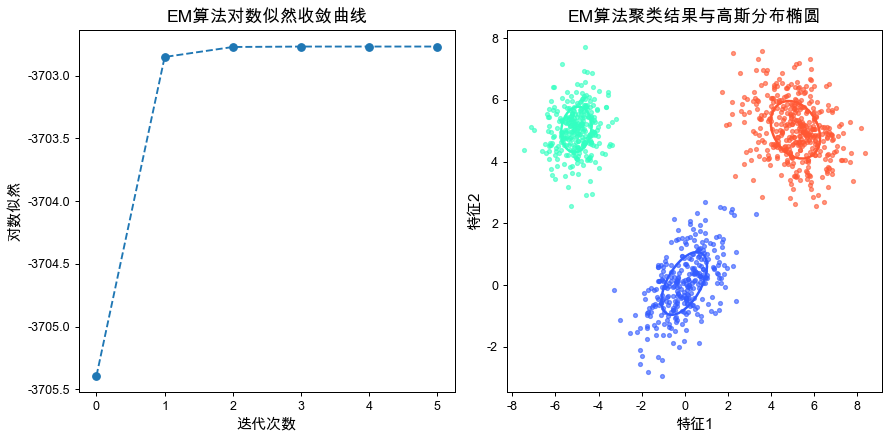

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse
np.random.seed(42)

# 1. 数据生成（3个二维高斯簇）
def generate_data(n_samples=500):
    # 三个簇的真实参数
    mus = [np.array([0, 0]), np.array([5, 5]), np.array([-5, 5])]
    covs = [np.array([[1.0, 0.5], [0.5, 1.0]]),
            np.array([[1.5, -0.3], [-0.3, 1.0]]),
            np.array([[0.5, 0.0], [0.0, 0.5]])]
    pis = [0.3, 0.4, 0.3]

    X = np.zeros((n_samples, 2))
    true_z = np.zeros(n_samples, dtype=int)
    for i in range(n_samples):
        # 按混合权重随机选择簇
        k = np.random.choice(len(pis), p=pis)
        X[i] = np.random.multivariate_normal(mus[k], covs[k])
        true_z[i] = k
    return X, true_z, mus, covs, pis

X, true_z, true_mus, true_covs, true_pis = generate_data(1000)

# 2. EM算法实现（GMM）
def initialize_parameters(X, n_components):
    n_samples, dim = X.shape
    # 随机初始化均值为数据子集
    indices = np.random.choice(n_samples, n_components, replace=False)
    mus = X[indices]
    # 初始化协方差为单位矩阵
    covs = [np.eye(dim) for _ in range(n_components)]
    # 等权重
    pis = np.ones(n_components) / n_components
    return mus, covs, pis

def gaussian_pdf(x, mu, cov):
    dim = x.shape[0]
    det_cov = np.linalg.det(cov)
    inv_cov = np.linalg.inv(cov)
    norm_const = 1.0 / (np.sqrt((2 * np.pi) ** dim * det_cov))
    diff = (x - mu).reshape(-1, 1)
    return norm_const * np.exp(-0.5 * diff.T.dot(inv_cov).dot(diff)).item()

def e_step(X, mus, covs, pis):
    n_samples, _ = X.shape
    n_components = len(pis)
    # 责任度矩阵 γ_{ik}
    gamma = np.zeros((n_samples, n_components))
    for i in range(n_samples):
        for k in range(n_components):
            gamma[i, k] = pis[k] * gaussian_pdf(X[i], mus[k], covs[k])
        gamma[i] /= np.sum(gamma[i])
    return gamma

def m_step(X, gamma):
    n_samples, dim = X.shape
    n_components = gamma.shape[1]
    Nks = np.sum(gamma, axis=0)
    mus = [np.sum(gamma[:, k].reshape(-1, 1) * X, axis=0) / Nks[k] for k in range(n_components)]
    covs = []
    for k in range(n_components):
        diff = X - mus[k]
        cov_k = (gamma[:, k].reshape(-1, 1) * diff).T.dot(diff) / Nks[k]
        covs.append(cov_k)
    pis = Nks / n_samples
    return mus, covs, pis

def compute_log_likelihood(X, mus, covs, pis):
    log_likelihood = 0.0
    for i in range(X.shape[0]):
        prob = 0
        for k in range(len(pis)):
            prob += pis[k] * gaussian_pdf(X[i], mus[k], covs[k])
        log_likelihood += np.log(prob)
    return log_likelihood

def em_gmm(X, n_components, tol=1e-4, max_iter=100):
    # 初始化参数
    mus, covs, pis = initialize_parameters(X, n_components)
    log_likelihoods = []

    for iteration in range(max_iter):
        # E步
        gamma = e_step(X, mus, covs, pis)
        # M步
        mus, covs, pis = m_step(X, gamma)
        # 计算对数似然
        ll = compute_log_likelihood(X, mus, covs, pis)
        log_likelihoods.append(ll)
        if iteration > 0 and np.abs(log_likelihoods[-1] - log_likelihoods[-2]) < tol:
            break
    return mus, covs, pis, gamma, log_likelihoods

# 运行EM算法
n_components = 3
mus_est, covs_est, pis_est, gamma, lls = em_gmm(X, n_components)

# 3. 可视化结果
plt.figure(figsize=(10, 5))

# 3.1 对数似然收敛
plt.subplot(1, 2, 1)
plt.plot(lls, marker='o', linestyle='--')
plt.title('EM算法对数似然收敛曲线', fontsize=14)
plt.xlabel('迭代次数', fontsize=12)
plt.ylabel('对数似然', fontsize=12)

# 3.2 聚类结果及高斯椭圆
plt.subplot(1, 2, 2)
colors = ['#FF5733', '#33FFC1', '#335BFF'] 
for i in range(n_components):
    # 散点图，按照软标签最大概率
    cluster = np.argmax(gamma, axis=1) == i
    plt.scatter(X[cluster, 0], X[cluster, 1], s=10, color=colors[i], alpha=0.6)
    # 画协方差椭圆
    vals, vecs = np.linalg.eigh(covs_est[i])
    angle = np.degrees(np.arctan2(*vecs[:,0][::-1]))
    width, height = 2 * np.sqrt(vals)
    ell = Ellipse(xy=mus_est[i], width=width, height=height, angle=angle,
                  edgecolor=colors[i], lw=2, facecolor='none')
    plt.gca().add_patch(ell)

plt.title('EM算法聚类结果与高斯分布椭圆', fontsize=14)
plt.xlabel('特征1', fontsize=12)
plt.ylabel('特征2', fontsize=12)
plt.tight_layout()
plt.show()

#### 1. 数据生成

- 构造3个高斯分布簇，各自指定真实均值 `mus`、协方差矩阵 `covs` 和权重 `pis`。
- 利用 `np.random.multivariate_normal` 按权重随机取样，生成1000个二维点 `X`。

#### 2. 参数初始化

- 从数据中随机选取 `n_components` 个样本作为初始均值。
- 将协方差初始化为单位矩阵，将混合权重初始化为等值。

#### 3. E步

- 计算每个样本在当前参数下属于每个高斯分布的责任度 `gamma[i,k]`。
- 使用标准高斯密度函数 `gaussian_pdf` 计算概率。

#### 4. M步

- 根据责任度 `gamma` 重估均值 `mus`、协方差 `covs` 和权重 `pis`，即“软分配”的MLE。

#### 5. 对数似然计算与收敛判断

- 每次迭代后计算整组数据的对数似然 `lls`，直到对数似然变化小于阈值 `tol`。

#### 6. 可视化

- 左图：对数似然随迭代次数收敛曲线。
- 右图：样本点按最高责任度聚类，并绘制估计的高斯协方差椭圆。

![原文参考图，当前结果见代码输出](attachments/img_009.png)

### 优缺点及适用场景

**优点**：

- 能处理隐变量（隐含类别标签）缺失的问题，广泛应用于混合模型参数估计。
- 每次迭代保证对数似然不下降（单调提升），易于收敛监控。
- 算法框架通用，可扩展到其他概率模型（如隐马尔可夫模型、矩阵分解等）。

**缺点**：

- 可能收敛到局部最优，而非全局最优；对初始化敏感。
- 在高维或数据量大时，E步和M步计算量较大，收敛较慢。
- 无法自动确定混合成分数，需要提前指定 `n_components`。

**适用场景**：

- 当数据中存在潜在的分布或类别，但标签缺失时。
- 当模型可以写成含隐变量的概率模型，且能够计算完整数据的对数似然时。

## 总结

EM 算法是一种用于含有隐变量的概率模型中参数估计的方法，尤其适用于数据不完全的情况。它通过在“E步”估计隐变量的分布，在“M步”更新参数，反复迭代提升模型对观测数据的似然值。

尽管易于实现且适用范围广，但EM算法可能收敛到局部最优，且对初始值敏感。